# Gaussian Random Functions and Emulators

A **random function** in ProbPipe is a distribution over functions.
`GaussianRandomFunction` is the core abstraction for models that
produce Gaussian predictive distributions at any set of inputs.

This notebook walks through:

1. Building a simple GP from scratch
2. The four joint prediction modes (shape semantics)
3. Fitting a GP to training data
4. Using `LinearBasisFunction` as a parametric model
5. Composing random functions with Gaussian algebra (`A @ grf + b`)
6. Function sampling (trajectory drawing)

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from probpipe import (
    GaussianRandomFunction,
    LinearBasisFunction,
    MultivariateNormal,
    Normal,
    set_return_approx_dist,
)
from probpipe import log_prob, mean, sample, variance

key = jax.random.PRNGKey(0)
set_return_approx_dist(False)

## 1. A Custom GP Emulator

The simplest emulator is a Gaussian process (GP).  To build one, subclass
`GaussianRandomFunction` and implement `predict_mean`, `predict_variance`,
and (for joint predictions) `predict_covariance`.

Below we create a zero-mean GP with a squared-exponential (RBF) kernel.

In [2]:
def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """Squared-exponential (RBF) kernel."""
    sq_dist = jnp.sum((X1[:, None, :] - X2[None, :, :]) ** 2, axis=-1)
    return variance * jnp.exp(-0.5 * sq_dist / lengthscale ** 2)


class ToyGP(GaussianRandomFunction):
    """Zero-mean GP prior with an RBF kernel."""

    supports_joint_inputs = True

    def __init__(self, lengthscale=1.0, variance=1.0, noise=1e-4):
        super().__init__(input_shape=(1,), output_shape=())
        self._ls = lengthscale
        self._var = variance
        self._noise = noise

    def predict_mean(self, X):
        extra_batch, n = self._parse_X(X)
        return jnp.zeros((*extra_batch, n))

    def predict_variance(self, X):
        extra_batch, n = self._parse_X(X)
        return jnp.full((*extra_batch, n), self._var)

    def predict_covariance(self, X, *, joint_inputs=False, joint_outputs=False):
        if not joint_inputs:
            raise NotImplementedError
        K = rbf_kernel(X, X, self._ls, self._var)
        return K + self._noise * jnp.eye(K.shape[-1])


gp = ToyGP(lengthscale=0.3, variance=1.0)
print(gp)

ToyGP(input_shape=(1,), output_shape=())


### 1.1 Prediction Inputs

We create test inputs.  Because `input_shape=(1,)`, each point is a 1-D
vector, so `X` has shape `(n, 1)`.

In [3]:
X = jnp.linspace(-2, 2, 6).reshape(-1, 1)  # (6, 1)
print(f"X.shape: {X.shape}")

X.shape: (6, 1)


### 1.2 The Four Joint Modes

Calling an `ArrayRandomFunction` returns a distribution whose
batch/event shape partition depends on two boolean flags:

| `joint_inputs` | `joint_outputs` | `event_shape` | `batch_shape` |
|:-:|:-:|:-:|:-:|
| False | False | `()` | `(*eb, n, *out)` |
| True  | False | `(n,)` | `(*eb, *out)` |
| False | True  | `(*out,)` | `(*eb, n)` |
| True  | True  | `(n, *out)` | `(*eb,)` |

**Mode 1** (default): independent marginals.

In [4]:
dist_marginal = gp(X)
print("Mode: joint_inputs=False, joint_outputs=False")
print(f"  type:        {type(dist_marginal).__name__}")
print(f"  batch_shape: {dist_marginal.batch_shape}")
print(f"  event_shape: {dist_marginal.event_shape}")

Mode: joint_inputs=False, joint_outputs=False
  type:        Normal
  batch_shape: (6,)
  event_shape: ()


**Mode 2**: `joint_inputs=True` — correlated across input points.

In [5]:
dist_joint_in = gp(X, joint_inputs=True)
print("Mode: joint_inputs=True, joint_outputs=False")
print(f"  type:        {type(dist_joint_in).__name__}")
print(f"  batch_shape: {dist_joint_in.batch_shape}")
print(f"  event_shape: {dist_joint_in.event_shape}")

Mode: joint_inputs=True, joint_outputs=False
  type:        MultivariateNormal
  batch_shape: ()
  event_shape: (6,)


### 1.4 Sampling and Visualization

Draw joint samples (smooth trajectories) from the GP prior.

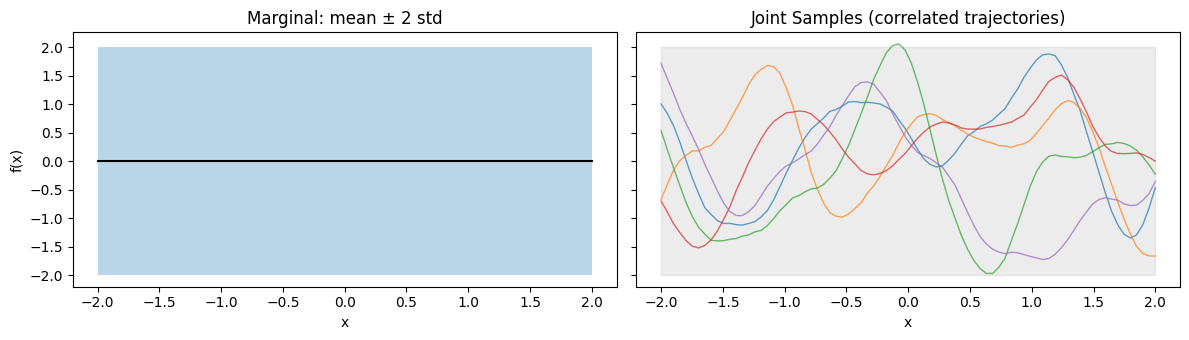

In [6]:
X_plot = jnp.linspace(-2, 2, 80).reshape(-1, 1)
k1, k2 = jax.random.split(key)

marginal = gp(X_plot)
joint = gp(X_plot, joint_inputs=True)

mu = jnp.asarray(mean(marginal))
std = jnp.sqrt(jnp.asarray(variance(marginal)))
trajectories = jnp.asarray(sample(joint, key=k1, sample_shape=(5,)))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)

ax = axes[0]
ax.fill_between(X_plot[:, 0], mu - 2*std, mu + 2*std, alpha=0.3)
ax.plot(X_plot[:, 0], mu, 'k-', lw=1.5)
ax.set(xlabel='x', ylabel='f(x)', title='Marginal: mean \u00b1 2 std')

ax = axes[1]
for i in range(5):
    ax.plot(X_plot[:, 0], trajectories[i], alpha=0.7, lw=1)
ax.fill_between(X_plot[:, 0], mu - 2*std, mu + 2*std, alpha=0.15, color='gray')
ax.set(xlabel='x', title='Joint Samples (correlated trajectories)')
plt.tight_layout()

## 2. GP with Training Data

Any `GaussianRandomFunction` subclass can store training data and
implement GP posterior equations. Below we build a GP that conditions
on observed data via standard posterior formulas.

In [7]:
class GPEmulator(GaussianRandomFunction):
    """GP with RBF kernel that can be fit to data."""

    supports_joint_inputs = True

    def __init__(self, lengthscale=1.0, variance=1.0, noise=0.01):
        super().__init__(input_shape=(1,), output_shape=())
        self._ls = lengthscale
        self._var = variance
        self._noise = noise
        self._X_train = None
        self._Y_train = None
        self._K_inv = None

    def fit(self, X, Y):
        self._X_train = jnp.asarray(X)
        self._Y_train = jnp.asarray(Y)
        K = rbf_kernel(self._X_train, self._X_train, self._ls, self._var)
        K += self._noise * jnp.eye(K.shape[0])
        self._K_inv = jnp.linalg.inv(K)

    # -- GaussianRandomFunction interface --

    def predict_mean(self, X):
        extra_batch, n = self._parse_X(X)
        if self._X_train is None:
            return jnp.zeros((*extra_batch, n))
        k_star = rbf_kernel(X, self._X_train, self._ls, self._var)
        return k_star @ self._K_inv @ self._Y_train

    def predict_variance(self, X):
        extra_batch, n = self._parse_X(X)
        if self._X_train is None:
            return jnp.full((*extra_batch, n), self._var)
        k_star = rbf_kernel(X, self._X_train, self._ls, self._var)
        return self._var - jnp.sum(k_star * (k_star @ self._K_inv), axis=-1)

    def predict_covariance(self, X, *, joint_inputs=False, joint_outputs=False):
        if not joint_inputs:
            raise NotImplementedError
        K_star = rbf_kernel(X, X, self._ls, self._var)
        if self._X_train is None:
            return K_star + self._noise * jnp.eye(K_star.shape[-1])
        k_cross = rbf_kernel(X, self._X_train, self._ls, self._var)
        return K_star - k_cross @ self._K_inv @ k_cross.T + 1e-6 * jnp.eye(K_star.shape[-1])


print(f"GPEmulator bases: {[c.__name__ for c in GPEmulator.__mro__[:5]]}")

GPEmulator bases: ['GPEmulator', 'GaussianRandomFunction', 'ArrayRandomFunction', 'RandomFunction', 'Distribution']


In [8]:
# Generate noisy training data
true_fn = lambda x: jnp.sin(3 * x) * jnp.exp(-0.3 * x ** 2)

X_train = jnp.array([-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5]).reshape(-1, 1)
Y_train = true_fn(X_train[:, 0]) + 0.1 * jax.random.normal(k2, shape=(7,))

# Fit the emulator
emu = GPEmulator(lengthscale=0.5, variance=1.0, noise=0.01)
emu.fit(X_train, Y_train)

print(f"isinstance(emu, GaussianRandomFunction): {isinstance(emu, GaussianRandomFunction)}")
print(f"Training points: {emu._X_train.shape[0]}")

isinstance(emu, GaussianRandomFunction): True
Training points: 7


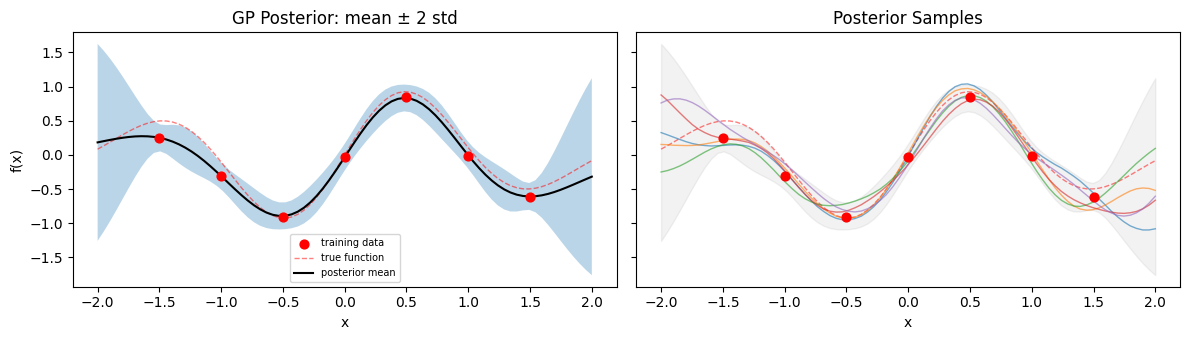

In [9]:
# Predict and plot
pred = emu(X_plot)
mu_post = jnp.asarray(mean(pred))
std_post = jnp.sqrt(jnp.asarray(variance(pred)))

# Joint samples from the posterior
k3, k4 = jax.random.split(k2)
joint_post = emu(X_plot, joint_inputs=True)
post_trajs = jnp.asarray(sample(joint_post, key=k3, sample_shape=(5,)))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)

for ax in axes:
    ax.scatter(X_train[:, 0], Y_train, c='red', s=40, zorder=5, label='training data')
    ax.plot(X_plot[:, 0], true_fn(X_plot[:, 0]), 'r--', lw=1, alpha=0.5, label='true function')

ax = axes[0]
ax.fill_between(X_plot[:, 0], mu_post - 2*std_post, mu_post + 2*std_post, alpha=0.3)
ax.plot(X_plot[:, 0], mu_post, 'k-', lw=1.5, label='posterior mean')
ax.set(xlabel='x', ylabel='f(x)', title='GP Posterior: mean \u00b1 2 std')
ax.legend(fontsize=7)

ax = axes[1]
for i in range(5):
    ax.plot(X_plot[:, 0], post_trajs[i], alpha=0.6, lw=1)
ax.fill_between(X_plot[:, 0], mu_post - 2*std_post, mu_post + 2*std_post, alpha=0.1, color='gray')
ax.set(xlabel='x', title='Posterior Samples')
plt.tight_layout()

## 3. Synthetic Likelihood Emulator

`GaussianRandomFunction` is not restricted to GPs — any model producing
Gaussian predictions can inherit from it.  Below is a simple synthetic
likelihood model that returns an independent Gaussian likelihood at each
input.  Because there are no cross-input correlations, we set
`supports_joint_inputs = False`.

In [10]:
class SyntheticLikelihoodEmulator(GaussianRandomFunction):
    """Each input gets an independent Gaussian likelihood."""

    supports_joint_inputs = False  # no cross-input correlations

    def __init__(self, noise_scale=0.2):
        super().__init__(input_shape=(1,), output_shape=())
        self._noise = noise_scale

    def predict_mean(self, X):
        return X[..., 0] ** 2  # Simple quadratic mean

    def predict_variance(self, X):
        return jnp.full(X[..., 0].shape, self._noise ** 2)


sl = SyntheticLikelihoodEmulator()
theta = jnp.array([[0.5], [1.0], [1.5], [2.0]])
dist_sl = sl(theta)

print(f'Input shape: {theta.shape}')
print(f'Output type: {type(dist_sl).__name__}')
print(f'batch_shape: {dist_sl.batch_shape}')
print(f'event_shape: {dist_sl.event_shape}')
print(f'Means:       {mean(dist_sl)}')

Input shape: (4, 1)
Output type: Normal
batch_shape: (4,)
event_shape: ()
Means:       NumericRecord(mean=array(shape=(4,)))


In [11]:
# Evaluate log-likelihood at observed data
y_obs = jnp.array([0.3, 1.1, 2.3, 3.9])
log_lik = jnp.asarray(log_prob(dist_sl, y_obs))
print(f'Log-likelihood at each input: {log_lik}')

# joint_inputs=True is NOT supported \u2014 verify the error
try:
    sl(theta, joint_inputs=True)
except ValueError as e:
    print(f'\nExpected error: {e}')

Log-likelihood at each input: [0.6592494 0.5654994 0.6592494 0.5654994]

Expected error: SyntheticLikelihoodEmulator does not support joint_inputs=True. This model can only return marginals over input points.


## 4. `LinearBasisFunction` as a Parametric Model

`LinearBasisFunction` models $f(x) = a + \Phi(x) w$ where $w \sim \mathcal{N}(m, C)$.
It can serve as a Bayesian linear regression model that can be fit
to data by updating the weight distribution analytically.

In [12]:
def poly_features(X, degree=5):
    """Polynomial feature map: [1, x, x^2, ..., x^degree]."""
    x = X[..., 0]
    return jnp.stack([x ** k for k in range(degree + 1)], axis=-1)


class BayesianPolynomial(LinearBasisFunction):
    """Bayesian polynomial regression model."""

    def __init__(self, degree=5, prior_scale=10.0):
        self._degree = degree
        d_w = degree + 1
        super().__init__(
            feature_map=lambda X: poly_features(X, degree),
            weights=MultivariateNormal(
                loc=jnp.zeros(d_w),
                cov=prior_scale * jnp.eye(d_w), name="auto_d1"
            ),
            input_shape=(1,),
        )
        self._X_train = None
        self._Y_train = None

    def fit(self, X, Y, noise_var=0.1):
        X, Y = jnp.asarray(X), jnp.asarray(Y)
        self._X_train, self._Y_train = X, Y

        phi = self._feature_map(X)
        prior_prec = jnp.linalg.inv(self._w_cov)
        C_post = jnp.linalg.inv(prior_prec + phi.T @ phi / noise_var)
        m_post = C_post @ (prior_prec @ self._w_mean + phi.T @ Y / noise_var)

        # Update weight distribution
        self._w_mean = m_post
        self._w_cov = C_post
        self._weights = MultivariateNormal(loc=m_post, cov=C_post, name="auto_d1")


# Fit to data
bp = BayesianPolynomial(degree=5)
bp.fit(X_train, Y_train)

print(f'Training points:     {bp._X_train.shape[0]}')
print(f'Weight dimensions:   {bp._w_mean.shape[0]}')
print(f'supports_joint_inputs: {bp.supports_joint_inputs}')

Training points:     7
Weight dimensions:   6
supports_joint_inputs: True


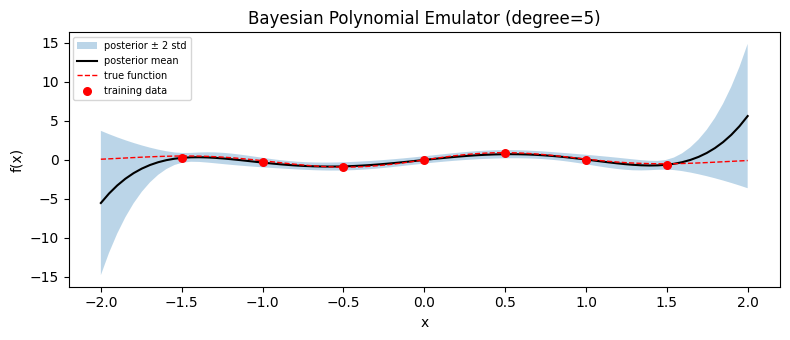

In [13]:
pred_bp = bp(X_plot)
mu_bp = jnp.asarray(mean(pred_bp))
std_bp = jnp.sqrt(jnp.asarray(variance(pred_bp)))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.fill_between(X_plot[:, 0], mu_bp - 2*std_bp, mu_bp + 2*std_bp, alpha=0.3, label='posterior \u00b1 2 std')
ax.plot(X_plot[:, 0], mu_bp, 'k-', lw=1.5, label='posterior mean')
ax.plot(X_plot[:, 0], true_fn(X_plot[:, 0]), 'r--', lw=1, label='true function')
ax.scatter(X_train[:, 0], Y_train, c='red', s=30, zorder=5, label='training data')
ax.set(xlabel='x', ylabel='f(x)', title='Bayesian Polynomial Emulator (degree=5)')
ax.legend(fontsize=7)
plt.tight_layout()

## 5. Gaussian Algebra

`GaussianRandomFunction` supports algebraic operations that preserve the
Gaussian property.  For example, `A @ grf + b` creates a new GRF whose
predictions are an affine transform of the base model's.  This is useful
for projecting a latent model into a different observation space.

input_shape:  (1,)
output_shape: (2,)


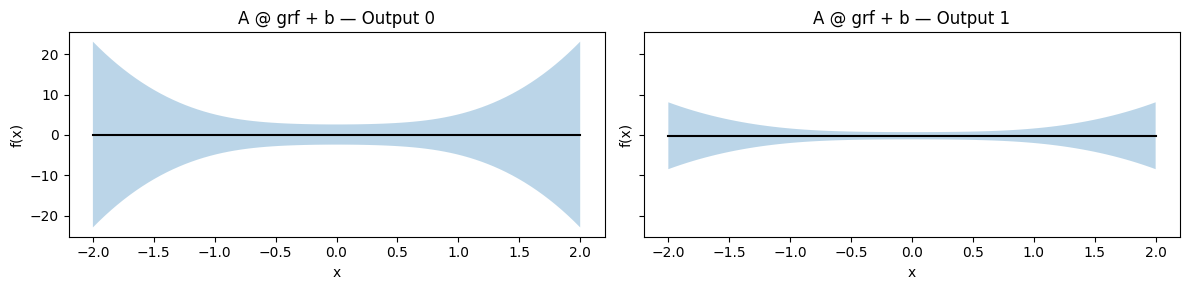

In [14]:
# Base function: scalar input -> 3-D latent output
def latent_features(X):
    x = X[..., 0]
    feats = jnp.stack([jnp.ones_like(x), x, x**2, x**3], axis=-1)  # (*eb, n, 4)
    return jnp.stack([feats, 0.5 * feats, 0.3 * feats], axis=-2)    # (*eb, n, 3, 4)

base_fn = LinearBasisFunction(
    feature_map=latent_features,
    weights=MultivariateNormal(loc=jnp.zeros(4), cov=jnp.eye(4), name="auto_d2"),
    input_shape=(1,),
    output_shape=(3,),
)

# Project 3-D latent -> 2-D observed via A @ grf + bias
A = jnp.array([[1.0, 0.5, 0.0], [0.0, 0.3, 1.0]])
projected = A @ base_fn + jnp.array([0.1, -0.2])

print(f'input_shape:  {projected.input_shape}')
print(f'output_shape: {projected.output_shape}')

pred_proj = projected(X_plot)
proj_mu = jnp.asarray(mean(pred_proj))      # (80, 2)
proj_std = jnp.sqrt(jnp.asarray(variance(pred_proj)))

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
for i, label in enumerate(['Output 0', 'Output 1']):
    ax = axes[i]
    ax.fill_between(X_plot[:, 0], proj_mu[:, i] - 2*proj_std[:, i],
                    proj_mu[:, i] + 2*proj_std[:, i], alpha=0.3)
    ax.plot(X_plot[:, 0], proj_mu[:, i], 'k-', lw=1.5)
    ax.set(xlabel='x', ylabel='f(x)', title=f'A @ grf + b \u2014 {label}')
plt.tight_layout()

## 6. Function Sampling

Finite-dimensional models like `LinearBasisFunction` support **function
sampling** \u2014 `sample()` returns a *callable* that evaluates the sampled
function at arbitrary inputs.  This is different from sampling the
predictive distribution at fixed points: here you get a single coherent
function realization.

In [15]:
k5, k6 = jax.random.split(k4)

# Draw 3 function realizations
g = sample(bp, key=k5, sample_shape=(3,))

print(f'Type: {type(g)}')
print(f'Callable? {callable(g)}')

# Evaluate at test points
X_traj = jnp.linspace(-2, 2, 50).reshape(-1, 1)
Y_traj = g(X_traj)  # (3, 50)
print(f'Output shape: {Y_traj.shape}')

# Consistency: same function, same inputs -> same outputs
Y_subset = g(X_traj[:5])
print(f'\nConsistent? {jnp.allclose(Y_traj[:, :5], Y_subset)}')

Type: <class 'probpipe.core.record.Record'>
Callable? True
Output shape: (3, 50)



Consistent? True


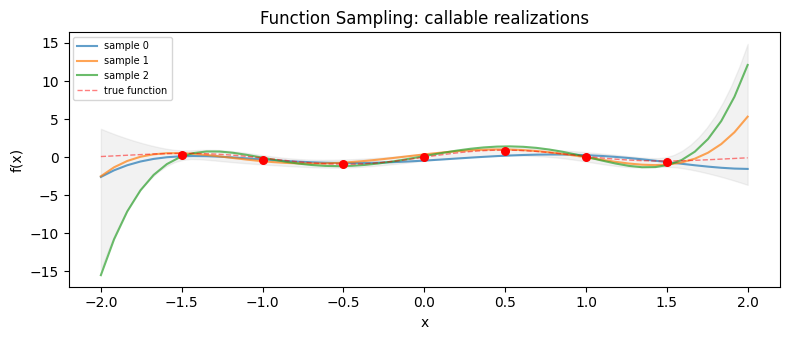

In [16]:
fig, ax = plt.subplots(figsize=(8, 3.5))
for i in range(3):
    ax.plot(X_traj[:, 0], Y_traj[i], alpha=0.7, lw=1.5, label=f'sample {i}')
ax.fill_between(X_plot[:, 0], mu_bp - 2*std_bp, mu_bp + 2*std_bp, alpha=0.1, color='gray')
ax.plot(X_plot[:, 0], true_fn(X_plot[:, 0]), 'r--', lw=1, alpha=0.5, label='true function')
ax.scatter(X_train[:, 0], Y_train, c='red', s=30, zorder=5)
ax.set(xlabel='x', ylabel='f(x)', title='Function Sampling: callable realizations')
ax.legend(fontsize=7)
plt.tight_layout()

## Summary

ProbPipe's random function design cleanly separates concerns:

| Concern | Abstraction | Role |
|:--------|:------------|:-----|
| Predictive model | `GaussianRandomFunction` | `predict_mean`, `predict_variance`, `predict_covariance` |
| Shape semantics | `ArrayRandomFunction` | `joint_inputs` / `joint_outputs` flags |
| Parametric models | `LinearBasisFunction` | Analytic Gaussian predictions + function sampling |
| Output projection | `A @ grf + b` | Gaussian algebra preserving Gaussian property |

**Key points:**

- Any model producing Gaussian predictions can be a `GaussianRandomFunction`
  (GPs, Bayesian linear regression, synthetic likelihood, etc.)
- The shape semantics (`joint_inputs` / `joint_outputs`) work uniformly
  across all concrete model types.
- Gaussian algebra (`A @ grf`, `grf + b`, `alpha * grf`, `grf1 + grf2`)
  produces new `GaussianRandomFunction` objects with analytically correct
  moments.
- Finite-dimensional models support `sample()` returning callables
  (coherent function realizations), not just pointwise samples.